#SATISFAÇÃO DO CLIENTE VS CATEGORIA

Tech Challenge - Análise de Satisfação no E-commerce - Satisfação x Categoria

Objetivos:


1.Análise das categorias de produtos com maior volume de vendas em 2018

2.Análise das categorias de produtos com maior volume de avaliações em 2018

3.Identificar a proporção de clientes
promotores, neutros e detratores.

4.Análise textual dos comentários de clientes promotores por meio de nuvem de palavras

5.Análise textual dos comentários de clientes detratores por meio de nuvem de palavras

IMPORTANTE: O dataset possui avaliações de 1 a 5 e não o NPS clássico (0-10).

Portanto, foi criada uma adaptação da metodologia:

Nota 4 e 5 -> Promotor
Nota 3 -> Neutro
Nota 1 e 2 -> Detrator

# Cruzando as tabelas

In [ ]:
#Libs - Bibliotecas importantes

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [ ]:
#carregando os data sets
df_nps = pd.read_csv('olist_order_reviews_dataset.csv')
df_categoria = pd.read_csv('olist_order_items_dataset.csv')
df_produto = pd.read_csv('olist_products_dataset.csv')
df_pagamento = pd.read_csv('olist_order_payments_dataset.csv')
df_externa = pd.read_csv('B2W-Reviews01.csv', sep=';')

/tmp/ipykernel_8906/2629182005.py:6: DtypeWarning: Columns (2,11,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,54,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df_externa = pd.read_csv('B2W-Reviews01.csv', sep=';')


In [ ]:
# Cruzando as tabelas
# 'inner' traz apenas os dados que existem em ambas as tabelas
tabela_cruzada = pd.merge(df_produto, df_categoria, on='product_id', how='inner')

# Exibindo as primeiras linhas do resultado
tabela_cruzada.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,e17e4f88e31525f7deef66779844ddce,1,5670f4db5b62c43d542e1b2d56b0cf7c,2018-04-30 17:33:54,10.91,7.39
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,5236307716393b7114b53ee991f36956,1,b561927807645834b59ef0d16ba55a24,2018-02-06 19:11:15,248.00,17.99
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,01f66e58769f84129811d43eefd187fb,1,7b07b3c7487f0ea825fc6df75abd658b,2018-07-11 21:30:20,79.80,7.82
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,143d00a4f2dde4e0364ee1821577adb3,1,c510bc1718f0f2961eaa42a23330681a,2018-08-07 09:10:13,112.30,9.54
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,86cafb8794cb99a9b1b77fc8e48fbbbb,1,0be8ff43f22e456b4e0371b2245e4d01,2018-04-17 01:30:23,37.90,8.29


In [ ]:
# Cruzando as tabelas
# 'inner' traz apenas os dados que existem em ambas as tabelas
tabela_intermediaria = pd.merge(tabela_cruzada, df_nps, on='order_id', how='inner')


In [ ]:
# Cruzando as tabelas
# 'inner' traz apenas os dados que existem em ambas as tabelas
tabela_final = pd.merge(tabela_intermediaria, df_pagamento, on='order_id', how='inner')

# Exibindo as primeiras linhas do resultado
tabela_final.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_id,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,e17e4f88e31525f7deef66779844ddce,...,d71da8fd8c6e3adef26be965f065b8a1,5,Vale a pena,Super adooorei o delineador ele é bem preto e ...,2018-04-28 00:00:00,2018-05-04 00:55:02,1,debit_card,1,18.30
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,5236307716393b7114b53ee991f36956,...,19866247db89845ef558ef19a6c26fcd,5,NaN,Excelente apontador! Em 3 segundos uma ponta p...,2018-02-17 00:00:00,2018-02-18 23:24:14,1,voucher,1,265.99
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,01f66e58769f84129811d43eefd187fb,...,32921b4e09c9a19d61fe46ce04231b84,5,NaN,NaN,2018-07-14 00:00:00,2018-07-16 16:20:04,1,credit_card,1,87.62
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,143d00a4f2dde4e0364ee1821577adb3,...,70949d129965fb1ee32aaccec720a19e,1,produto divergente,modelo comprado: travesseiro memoria carinho B...,2018-08-07 00:00:00,2018-08-08 11:53:04,1,credit_card,2,121.84
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,86cafb8794cb99a9b1b77fc8e48fbbbb,...,74c9c7d0bc153bbbc92e4c1597b8ba55,5,NaN,NaN,2018-04-17 00:00:00,2018-04-18 04:29:47,1,credit_card,4,46.19


# Criando Classificação da Nota

In [24]:
# Criando a coluna de classificação da nota
conditions = [
    (tabela_final['review_score'] >= 4),
    (tabela_final['review_score'] == 3),
    (tabela_final['review_score'] >= 0) & (tabela_final['review_score'] <= 2)
]
choices = ['promotor', 'neutro', 'detrator']

tabela_final['classificacao_nota'] = np.select(conditions, choices, default='desconhecido')

# Exibindo as primeiras mil linhas com a nova coluna
tabela_final[['review_score', 'classificacao_nota']].iloc[:1000]

,review_score,classificacao_nota
0,5,promotor
1,5,promotor
2,5,promotor
3,1,detrator
4,5,promotor
...,...,...
995,5,promotor
996,3,neutro
997,5,promotor
998,4,promotor


# Grafico com os 10 produtos mais avaliados em 2018

A análise das categorias mais avaliadas em 2018 permite identificar os produtos com maior volume de feedbacks dos clientes, oferecendo uma base consistente para avaliar a satisfação do consumidor e compreender quais áreas do e-commerce possuem maior relevância na experiência de compra. Neste sentido a categoria "cama, mesa e banho" é a que mais recebeu feedbacks com 6389 avaliações em 2018.

In [25]:
# Certifique-se de que a coluna 'review_creation_date' está no formato datetime
tabela_final['review_creation_date'] = pd.to_datetime(tabela_final['review_creation_date'])

# Filtrar os dados para o ano de 2018
tabela_final_2018 = tabela_final[tabela_final['review_creation_date'].dt.year == 2018]

# Agrupar por categoria de produto e contar o número total de avaliações para 2018
reviews_por_categoria_2018 = tabela_final_2018.groupby('product_category_name').size().nlargest(10).reset_index(name='total_reviews')

# Renomear a coluna para clareza no gráfico
reviews_por_categoria_2018.rename(columns={'product_category_name': 'Categoria do Produto'}, inplace=True)

# Função para adicionar quebras de linha em rótulos longos
def wrap_labels(label, max_len=15):
    # Prioritize breaking at underscores
    if '_' in label:
        return '<br>'.join(label.split('_'))
    # Fallback to character limit if no underscores and label is too long
    elif len(label) > max_len:
        words = label.split(' ')
        wrapped_label = []
        current_line = ""
        for word in words:
            if len(current_line) + len(word) + 1 > max_len and current_line:  # +1 for space
                wrapped_label.append(current_line)
                current_line = word
            else:
                if current_line:
                    current_line += ' ' + word
                else:
                    current_line = word
        wrapped_label.append(current_line)
        return '<br>'.join(wrapped_label)
    return label

# Aplicar a função para criar uma nova coluna com rótulos formatados
reviews_por_categoria_2018['Categoria do Produto'] = reviews_por_categoria_2018['Categoria do Produto'].apply(wrap_labels)

# Criar o gráfico de barras com Plotly Express
fig = px.bar(
    reviews_por_categoria_2018,
    x='Categoria do Produto', # Usar a coluna formatada para o eixo X
    y='total_reviews',
    title='Categorias de produtos com maior volume de avaliações em 2018',
    labels={'total_reviews': 'Quantidade de Avaliações'},
    color='total_reviews',
    color_continuous_scale=px.colors.sequential.Blues, # Changed to a blue sequential scale
    text_auto=True # Adicionar esta linha para exibir o número natural no topo das barras
)

# Definir o fundo do gráfico como branco e ajustar o layout (título centralizado e rotação do eixo x)
fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    title_x=0.2,
    xaxis_tickangle=0, # Manter os rótulos horizontais
    coloraxis_showscale=False
)

# Exibir o gráfico
fig.show()

# Taxa de Promotor Neutro e Detrator dentro desses 10 produtos

A análise do perfil de satisfação dos clientes nas categorias mais avaliadas em 2018 permite compreender como os consumidores se distribuem entre promotores, neutros e detratores nos segmentos com maior volume de feedbacks. Essa visão é importante porque ajuda a identificar se as categorias com maior participação dos clientes também apresentam uma percepção positiva em relação à experiência de compra.

Notamos uma predominância de clientes promotores, pois em todas as categorias analisadas, esses clientes representam a maior parte das avaliações, indicando uma percepção majoritariamente positiva da experiência de compra nas categorias com maior volume de feedbacks.

In [26]:
# Obter a lista das top 10 categorias de produtos com mais avaliações em 2018 (usando nomes originais para filtragem)
# Temporariamente obter os 10 principais nomes de categoria originais de tabela_final_2018
original_top_10_category_names = tabela_final_2018.groupby('product_category_name').size().nlargest(10).index.tolist()

# Filtrar a tabela_final_2018 para incluir apenas essas top 10 categorias originais
df_top_10_categorias_2018 = tabela_final_2018[tabela_final_2018['product_category_name'].isin(original_top_10_category_names)].copy()

# Contar a ocorrência de cada classificação (promotor, neutro, detrator) por categoria
classificacao_por_categoria_top_10 = df_top_10_categorias_2018.groupby(['product_category_name', 'classificacao_nota']).size().unstack(fill_value=0)

# Calcular as porcentagens
classificacao_por_categoria_top_10_percent = classificacao_por_categoria_top_10.div(classificacao_por_categoria_top_10.sum(axis=1), axis=0) * 100

# Resetar o índice para usar as colunas no Plotly Express
df_plot_top_10 = classificacao_por_categoria_top_10_percent.reset_index()

# Aplicar a função wrap_labels aos nomes das categorias para exibição no gráfico
df_plot_top_10['product_category_name_formatted'] = df_plot_top_10['product_category_name'].apply(wrap_labels)

# Melt o DataFrame para o formato 'long' exigido pelo Plotly para gráficos de barras empilhadas
df_plot_top_10_melted = df_plot_top_10.melt(id_vars=['product_category_name', 'product_category_name_formatted'], var_name='Classificação', value_name='Percentual de clientes por classificação')

# Capitalizar a primeira letra de cada palavra na coluna 'Classificação'
df_plot_top_10_melted['Classificação'] = df_plot_top_10_melted['Classificação'].apply(lambda x: ' '.join([word.capitalize() for word in x.split()]))

# Exibir as 10 primeiras linhas da tabela
display(df_plot_top_10_melted.head(10))


,product_category_name,product_category_name_formatted,Classificação,Percentual de clientes por classificação
0,automotivo,automotivo,Detrator,14.996421
1,beleza_saude,beleza<br>saude,Detrator,13.788680
2,cama_mesa_banho,cama<br>mesa<br>banho,Detrator,19.799656
3,esporte_lazer,esporte<br>lazer,Detrator,16.476920
4,ferramentas_jardim,ferramentas<br>jardim,Detrator,16.437707
5,informatica_acessorios,informatica<br>acessorios,Detrator,19.576508
6,moveis_decoracao,moveis<br>decoracao,Detrator,19.810683
7,relogios_presentes,relogios<br>presentes,Detrator,17.597977
8,telefonia,telefonia,Detrator,17.858554
9,utilidades_domesticas,utilidades<br>domesticas,Detrator,16.493895


# Comentarios dos clientes detratores

A análise dos termos mais recorrentes nos comentários de clientes detratores permite identificar os principais fatores associados à insatisfação na experiência de compra. Diferente dos promotores, que destacam aspectos positivos como qualidade e entrega antes do prazo, os detratores concentram seus comentários em problemas relacionados ao pedido, atendimento, devolução, nota fiscal e expectativa não atendida.
Termos como “nota fiscal”, “até momento”, “até hoje”, “dinheiro volta”, “entrar contato” e “solicitei devolução” indicam que a insatisfação dos clientes detratores está fortemente relacionada a falhas operacionais no pós-venda, como dificuldade de atendimento, ausência de retorno, problemas com documentação fiscal e processos de devolução ou reembolso.

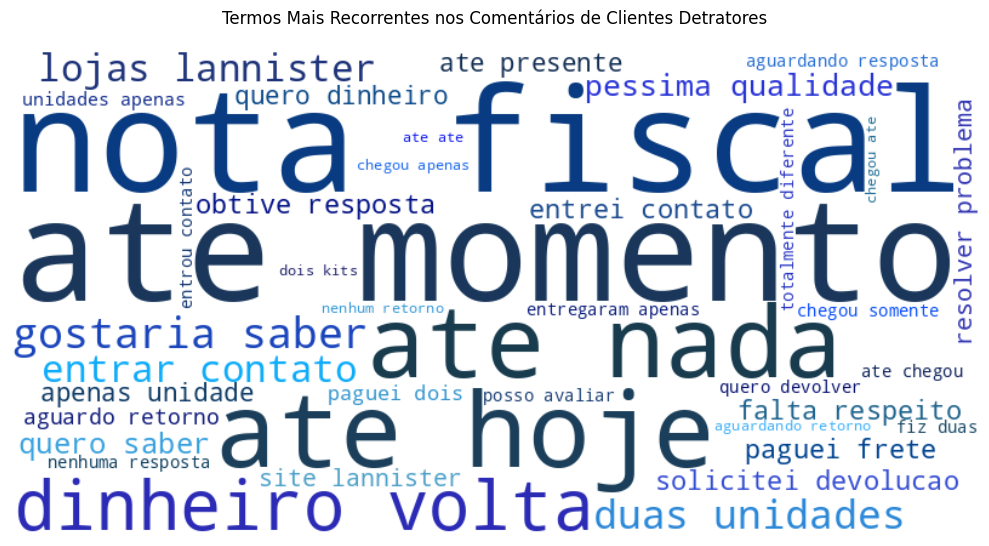

In [27]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
from collections import Counter
import random
import unicodedata
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
import nltk
import os

# Create a dedicated directory for NLTK data if it doesn't exist
# There was a typo here, should be `nltk_data_path` instead of `ltk_data_path`
nltk_data_path = './nltk_data'
if not os.path.exists(nltk_data_path):
    os.makedirs(nltk_data_path)

# Add this dedicated directory to NLTK's data path
nltk.data.path.append(nltk_data_path)

# Download NLTK data if not already present, to the dedicated directory
# Handle 'stopwords'
try:
    nltk.data.find('corpora/stopwords', paths=[nltk_data_path])
except LookupError:
    nltk.download('stopwords', quiet=True, download_dir=nltk_data_path)

# Handle 'punkt'
try:
    nltk.data.find('tokenizers/punkt', paths=[nltk_data_path])
except LookupError:
    nltk.download('punkt', quiet=True, download_dir=nltk_data_path)

# Handle 'punkt_tab' specifically as per the error message
try:
    nltk.data.find('tokenizers/punkt_tab', paths=[nltk_data_path])
except LookupError:
    nltk.download('punkt_tab', quiet=True, download_dir=nltk_data_path)

# Function to remove accents
def remove_accents(input_str):
    if not isinstance(input_str, str):
        return input_str
    nfkd_form = unicodedata.normalize('NFKD', input_str)
    return ''.join([c for c in nfkd_form if not unicodedata.combining(c)])

# Custom text cleaning function
def clean_text(text, custom_stopwords):
    # Convert to lowercase
    text = text.lower()
    # Remove accents
    text = remove_accents(text)
    # Remove punctuation, numbers, and special characters, keep only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize words
    words = word_tokenize(text, language='portuguese')
    # Remove stopwords and short words
    words = [word for word in words if word not in custom_stopwords and len(word) > 2]
    return words

# Custom color function for shades of blue (for promoters)
def blue_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return "hsl(%d, %d%%, %d%%)" % (random.randint(200, 240), random.randint(50, 100), random.randint(20, 60))

# Custom color function for shades of red (for detractors)
def red_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    # Hue for red is typically around 0. Using a range from 0 to 20.
    # Saturation from 50% to 100% for intense colors.
    # Lightness from 20% to 60% to ensure darker shades.
    return "hsl(%d, %d%%, %d%%)" % (random.randint(0, 20), random.randint(50, 100), random.randint(20, 60))


# --- Define Stop Words ---
# Common Portuguese stop words
portuguese_stopwords = set(stopwords.words('portuguese'))

# Custom e-commerce specific stop words as requested by the user
custom_ecommerce_stopwords = {
    "produto", "produtos", "compra", "comprei", "loja", "pedido", "recebi", "veio", "entregue",
    "entrega", "prazo",
    "muito", "bem", "pouco", "fazer", "assim", "agora", "ja", "ainda", "dia", "mes", "ano", "vez", "mesmo", "toda", "tudo",
    "quase", "fica", "fiquei", "sem", "mim", "ser", "foi", "bom", "boa", "ok", "aqui", "la", "qual", "parte", "nao"
}

all_stopwords = portuguese_stopwords.union(custom_ecommerce_stopwords)

# --- Bigram Analysis Function ---
def generate_bigrams(word_list):
    bigrams = list(ngrams(word_list, 2))
    return [" ".join(bigram) for bigram in bigrams]

# --- Set max_words for bigrams ---
max_words_bigram = 40


# --- Promotor Bigram Analysis ---
promotor_comments_df = df_top_10_categorias_2018[df_top_10_categorias_2018['classificacao_nota'] == 'promotor']
text_promotor = promotor_comments_df['review_comment_message'].dropna().astype(str)
all_promotor_comments = " ".join(text_promotor)
cleaned_promotor_words = clean_text(all_promotor_comments, all_stopwords)
promotor_bigrams = generate_bigrams(cleaned_promotor_words)
promotor_bigram_counts = Counter(promotor_bigrams)
top_promotor_bigrams = dict(promotor_bigram_counts.most_common(max_words_bigram))


# --- Detractor Bigram Analysis ---
detrator_comments_df = df_top_10_categorias_2018[df_top_10_categorias_2018['classificacao_nota'] == 'detrator']
text_detrator = detrator_comments_df['review_comment_message'].dropna().astype(str)
all_detrator_comments = " ".join(text_detrator)
cleaned_detrator_words = clean_text(all_detrator_comments, all_stopwords)
detrator_bigrams = generate_bigrams(cleaned_detrator_words)
detrator_bigram_counts = Counter(detrator_bigrams)
top_detrator_bigrams = dict(detrator_bigram_counts.most_common(max_words_bigram))


# --- Plotting Detractor Bigram Word Cloud ---
fig, ax = plt.subplots(1, 1, figsize=(10, 8)) # Adjusted to a single subplot

# Detractor Bigram Word Cloud
wordcloud_detrator_bigram = WordCloud(
    width=800, height=400, background_color='white', collocations=False,
    color_func=blue_color_func, max_words=max_words_bigram
).generate_from_frequencies(top_detrator_bigrams)
ax.imshow(wordcloud_detrator_bigram, interpolation='bilinear') # Use 'ax' for the single subplot
ax.axis('off')
ax.set_title('Termos Mais Recorrentes nos Comentários de Clientes Detratores', pad=20) # Updated title

plt.tight_layout(rect=[0, 0, 1, 0.80])
plt.show()

# Comentarios dos clientes promotores

A análise dos termos mais recorrentes nos comentários de clientes promotores permite compreender quais aspectos da experiência de compra estão mais associados à satisfação e à recomendação. Ao observar as palavras e expressões mais frequentes, é possível identificar fatores percebidos positivamente pelos consumidores, como qualidade do produto, cumprimento do prazo de entrega e percepção de bom atendimento.

Os termos com maior destaque, como “chegou antes”, “antes previsto”, “super recomendo”, “ótima qualidade” e “perfeito estado”, indicam que os clientes promotores valorizam principalmente a entrega antes do prazo e a qualidade do produto recebido. Isso sugere que a satisfação positiva está fortemente relacionada à eficiência logística e ao cumprimento das expectativas criadas no momento da compra.

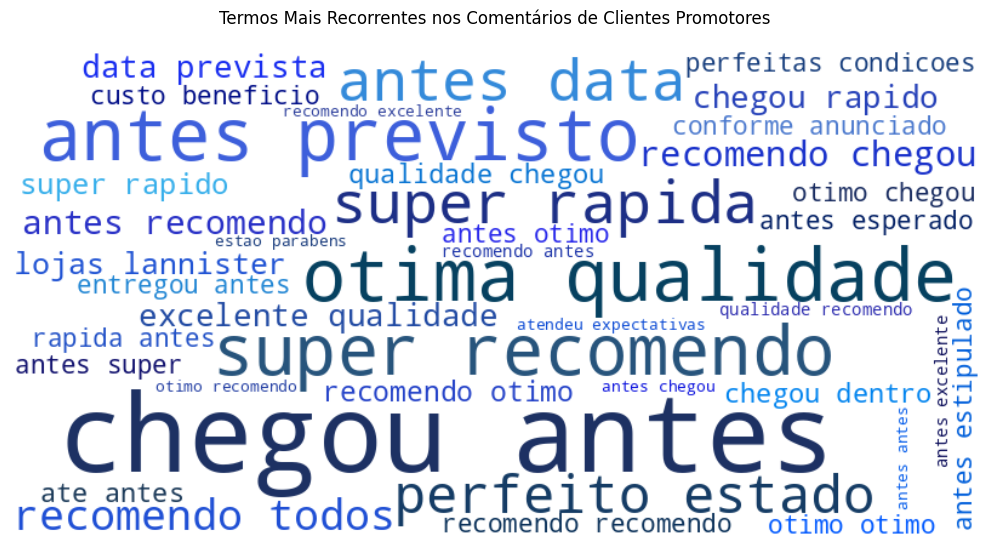

In [28]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re
from collections import Counter
import random
import unicodedata
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.util import ngrams
import nltk
import os

# Create a dedicated directory for NLTK data if it doesn't exist
nltk_data_path = './nltk_data'
if not os.path.exists(nltk_data_path):
    os.makedirs(nltk_data_path)

# Add this dedicated directory to NLTK's data path
nltk.data.path.append(nltk_data_path)

# Download NLTK data if not already present, to the dedicated directory
# Handle 'stopwords'
try:
    nltk.data.find('corpora/stopwords', paths=[nltk_data_path])
except LookupError:
    nltk.download('stopwords', quiet=True, download_dir=nltk_data_path)

# Handle 'punkt'
try:
    nltk.data.find('tokenizers/punkt', paths=[nltk_data_path])
except LookupError:
    nltk.download('punkt', quiet=True, download_dir=nltk_data_path)

# Handle 'punkt_tab' specifically as per the error message
try:
    nltk.data.find('tokenizers/punkt_tab', paths=[nltk_data_path])
except LookupError:
    nltk.download('punkt_tab', quiet=True, download_dir=nltk_data_path)

# Function to remove accents
def remove_accents(input_str):
    if not isinstance(input_str, str):
        return input_str
    nfkd_form = unicodedata.normalize('NFKD', input_str)
    return ''.join([c for c in nfkd_form if not unicodedata.combining(c)])

# Custom text cleaning function
def clean_text(text, custom_stopwords):
    # Convert to lowercase
    text = text.lower()
    # Remove accents
    text = remove_accents(text)
    # Remove punctuation, numbers, and special characters, keep only letters and spaces
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize words
    words = word_tokenize(text, language='portuguese')
    # Remove stopwords and short words
    words = [word for word in words if word not in custom_stopwords and len(word) > 2]
    return words

# Custom color function for shades of blue (for promoters)
def blue_color_func(word, font_size, position, orientation, random_state=None, **kwargs):
    return "hsl(%d, %d%%, %d%%)" % (random.randint(200, 240), random.randint(50, 100), random.randint(20, 60))


# --- Define Stop Words ---
# Common Portuguese stop words
portuguese_stopwords = set(stopwords.words('portuguese'))

# Custom e-commerce specific stop words as requested by the user
custom_ecommerce_stopwords = {
    "produto", "produtos", "compra", "comprei", "loja", "pedido", "recebi", "veio", "entregue",
    "entrega", "prazo",
    "muito", "bem", "pouco", "fazer", "assim", "agora", "ja", "ainda", "dia", "mes", "ano", "vez", "mesmo", "toda", "tudo",
    "quase", "fica", "fiquei", "sem", "mim", "ser", "foi", "bom", "boa", "ok", "aqui", "la", "qual", "parte", "nao"
}

all_stopwords = portuguese_stopwords.union(custom_ecommerce_stopwords)

# --- Extract and Clean Comments ---
# Promotor comments
promotor_comments_df = df_top_10_categorias_2018[df_top_10_categorias_2018['classificacao_nota'] == 'promotor']
text_promotor = promotor_comments_df['review_comment_message'].dropna().astype(str)
all_promotor_comments = " ".join(text_promotor)
cleaned_promotor_words = clean_text(all_promotor_comments, all_stopwords)

# --- Bigram Analysis ---
def generate_bigrams(word_list):
    bigrams = list(ngrams(word_list, 2))
    return [" ".join(bigram) for bigram in bigrams]

# Set max_words_bigram to 40 as requested
max_words_bigram = 40

# Promotor bigrams
promotor_bigrams = generate_bigrams(cleaned_promotor_words)
promotor_bigram_counts = Counter(promotor_bigrams)
top_promotor_bigrams = dict(promotor_bigram_counts.most_common(max_words_bigram))


# --- Plotting Promotor Bigram Word Cloud ---
fig_bigrams, ax = plt.subplots(1, 1, figsize=(10, 8)) # Adjusted to a single subplot

# Promotor Bigram Word Cloud
wordcloud_promotor_bigram = WordCloud(
    width=800, height=400, background_color='white', collocations=False,
    color_func=blue_color_func, max_words=max_words_bigram
).generate_from_frequencies(top_promotor_bigrams)
ax.imshow(wordcloud_promotor_bigram, interpolation='bilinear') # Use 'ax' for the single subplot
ax.axis('off')
ax.set_title('Termos Mais Recorrentes nos Comentários de Clientes Promotores', pad=20) # Added title back with padding

# Removed suptitle and ax.set_title to remove titles from the plot
plt.tight_layout(rect=[0, 0, 1, 0.80])
plt.show()

# Base Externa - Categorias de produtos com maior volume de avaliações em 2018


O Grafico abaixo é referente aos dados externos obtidos partir do repositório público b2w-reviews01, disponibilizado pela Americanas-Tech/B2W Digital no GitHub. Essa base reúne avaliações de consumidores em um cenário de e-commerce, permitindo análises relacionadas à satisfação do cliente.

A base externa utilizada neste projeto é o dataset público B2W-Reviews01, disponibilizado pela Americanas-Tech/B2W Digital. Trata-se de um conjunto de dados composto por avaliações de produtos realizadas por clientes da Americanas.com entre janeiro e maio de 2018.

Essa base contém mais de 130 mil avaliações de consumidores e reúne informações relevantes para análises de satisfação, como nota geral do produto, texto do comentário, título da avaliação, categoria do produto, marca, estado do avaliador e indicação se o cliente recomendaria ou não o produto a um amigo.

No contexto deste estudo, a base B2W-Reviews01 foi utilizada como fonte externa de comparação, permitindo observar semelhanças e diferenças em relação à base principal trabalhada no Colab. Essa comparação contribui para ampliar a análise sobre categorias mais avaliadas, comportamento dos consumidores e padrões de satisfação em diferentes bases de e-commerce.

In [31]:
import pandas as pd
import plotly.express as px

# Certifique-se de que a coluna 'submission_date' está no formato datetime
df_externa['submission_date'] = pd.to_datetime(df_externa['submission_date'], format='%d/%m/%Y %H:%M')

# Filtrar os dados para o ano de 2018
df_externa_2018 = df_externa[df_externa['submission_date'].dt.year == 2018]

# Função para adicionar quebras de linha em rótulos longos (re-definida para garantir escopo)
def wrap_labels(label, max_len=15):
    # Priorize breaking at underscores
    if '_' in label:
        return '<br>'.join(label.split('_'))
    # Fallback to character limit if no underscores and label is too long
    elif len(label) > max_len:
        words = label.split(' ')
        wrapped_label = []
        current_line = ""
        for word in words:
            if len(current_line) + len(word) + 1 > max_len and current_line:  # +1 for space
                wrapped_label.append(current_line)
                current_line = word
            else:
                if current_line:
                    current_line += ' ' + word
                else:
                    current_line = word
        wrapped_label.append(current_line)
        return '<br>'.join(wrapped_label)
    return label

# Agrupar por categoria de produto e contar o número total de avaliações para 2018
# Usando 'site_category_lv1' como a coluna de categoria de produto
reviews_por_categoria_externa_2018 = df_externa_2018.groupby('site_category_lv1').size().nlargest(10).reset_index(name='total_reviews')

# Renomear a coluna para clareza no gráfico
reviews_por_categoria_externa_2018.rename(columns={'site_category_lv1': 'Categoria do Produto'}, inplace=True)

# Aplicar a função para criar uma nova coluna com rótulos formatados
reviews_por_categoria_externa_2018['Categoria do Produto'] = reviews_por_categoria_externa_2018['Categoria do Produto'].apply(wrap_labels)

# Exibir as 10 primeiras linhas da tabela
display(reviews_por_categoria_externa_2018.head(10))

,Categoria do Produto,total_reviews
0,Celulares e<br>Smartphones,20842
1,Eletroportáteis,11730
2,Beleza e<br>Perfumaria,8957
3,Utilidades<br>Domésticas,8184
4,TV e Home<br>Theater,7557
5,Informática e<br>Acessórios,7462
6,Móveis,7157
7,Brinquedos,4708
8,Casa e<br>Construção,4465
9,Informática,4259


# Volume de Avaliações das Categorias em Comum entre Base Principal e Base Externa

A diferença no volume de avaliações entre as bases pode estar relacionada ao tamanho dos datasets, uma vez que a Base Colab possui 101.507 registros, enquanto a Base Externa contém 128.245 registros. No comparativo, a Base Externa apresenta maior volume em todas as categorias analisadas, com destaque para “Utilidades Domésticas”, que possui a maior variação entre as bases: 4.341 avaliações na Base Colab contra 8.184 na Base Externa.

In [32]:
import plotly.express as px
import pandas as pd
import numpy as np
import re
import unicodedata

# --- Helper Functions (Ensuring self-containment) ---
def remove_accents(input_str):
    if not isinstance(input_str, str):
        return input_str
    nfkd_form = unicodedata.normalize('NFKD', input_str)
    return ''.join([c for c in nfkd_form if not unicodedata.combining(c)])

def standardize_category_name(category_name):
    if pd.isna(category_name):
        return None
    standardized = remove_accents(str(category_name)).lower().strip()
    standardized = re.sub(r'\s+', ' ', standardized)

    # Specific mappings for external data categories
    if 'beleza' in standardized: # 'Beleza e Perfumaria' -> 'beleza'
        return 'beleza'
    elif 'utilidades domesticas' in standardized: # 'Utilidades Domésticas' -> 'utilidades domesticas'
        return 'utilidades domesticas'
    elif 'informatica' in standardized and 'acessorios' in standardized: # 'Informática e Acessórios' -> 'informatica acessorios'
        return 'informatica acessorios'
    elif 'moveis' in standardized: # 'Móveis' -> 'moveis'
        return 'moveis'

    # Specific mappings for internal data (Olist) categories
    if standardized in ['perfumaria', 'beleza_saude', 'beleza_e_saude']:
        return 'beleza'
    if standardized in ['eletrodomesticos', 'utilidades_domesticas']:
        return 'utilidades domesticas'
    if standardized in ['informatica_acessorios']:
        return 'informatica acessorios'
    if standardized in ['moveis_decoracao', 'moveis_estofados', 'moveis_cozinha_area_servico_jantar_e_estar']:
        return 'moveis'
    return standardized

# The `wrap_labels` function is already in the original cell, keep it.
def wrap_labels(label, max_len=15):
    # Priorize breaking at underscores
    if '_' in label:
        return '<br>'.join(label.split('_'))
    # Fallback to character limit if no underscores and label is too long
    elif len(label) > max_len:
        words = label.split(' ')
        wrapped_label = []
        current_line = ""
        for word in words:
            if len(current_line) + len(word) + 1 > max_len and current_line:  # +1 for space
                wrapped_label.append(current_line)
                current_line = word
            else:
                if current_line:
                    current_line += ' ' + word
                else:
                    current_line = word
        wrapped_label.append(current_line)
        return '<br>'.join(wrapped_label)
    return label

def format_num_k(value):
    if pd.isna(value):
        return None
    value = int(value)
    if value >= 1000:
        # Format for thousands, using '.' as thousands separator (Portuguese locale style) and append 'k'
        # For example, 12087 becomes '12.087k'
        return f'{value:,.0f}'.replace(',', '.') + 'k'
    else:
        # For numbers less than 1000, just display the number as is
        return str(value)
# --- End Helper Functions ---

# --- Data Preparation (Ensuring tabela_final_2018 and df_externa_2018 are correctly set up) ---
# Assuming df_nps, df_categoria, df_produto, df_pagamento, df_externa are loaded from previous cells
# Re-create tabela_final to ensure all merges are up-to-date
df_nps = pd.read_csv('olist_order_reviews_dataset.csv')
df_categoria = pd.read_csv('olist_order_items_dataset.csv')
df_produto = pd.read_csv('olist_products_dataset.csv')
df_pagamento = pd.read_csv('olist_order_payments_dataset.csv')
df_externa = pd.read_csv('B2W-Reviews01.csv', sep=';', low_memory=False) # Reload with low_memory=False to prevent DtypeWarning

# Cruzando as tabelas
tabela_cruzada = pd.merge(df_produto, df_categoria, on='product_id', how='inner')
tabela_intermediaria = pd.merge(tabela_cruzada, df_nps, on='order_id', how='inner')
tabela_final = pd.merge(tabela_intermediaria, df_pagamento, on='order_id', how='inner')

# Ensure review_creation_date and submission_date are datetime objects
tabela_final['review_creation_date'] = pd.to_datetime(tabela_final['review_creation_date'])
df_externa['submission_date'] = pd.to_datetime(df_externa['submission_date'], format='%d/%m/%Y %H:%M', errors='coerce')

# Filter for 2018 data
tabela_final_2018 = tabela_final[tabela_final['review_creation_date'].dt.year == 2018].copy()
df_externa_2018 = df_externa[df_externa['submission_date'].dt.year == 2018].copy()

# Add standardized category names to both dataframes
tabela_final_2018['standardized_category'] = tabela_final_2018['product_category_name'].apply(standardize_category_name)
df_externa_2018['standardized_category'] = df_externa_2018['site_category_lv1'].apply(standardize_category_name)

# Define common standardized categories and their wrapped names (from kernel state)
common_categories_standardized = ['beleza', 'utilidades domesticas', 'informatica acessorios', 'moveis']
category_to_wrapped_name = {'beleza': 'Beleza e<br>Perfumaria', 'utilidades domesticas': 'Utilidades<br>Domésticas', 'informatica acessorios': 'Informática e<br>Acessórios', 'moveis': 'Móveis'}

# --- Create df_common_categories ---
# Data from 'Base Colab' (tabela_final_2018)
colab_common_reviews_df = tabela_final_2018[
    tabela_final_2018['standardized_category'].isin(common_categories_standardized)
].groupby('standardized_category').size().reset_index(name='total_reviews')
colab_common_reviews_df['Base de Dados'] = 'Base Colab'
colab_common_reviews_df.rename(columns={'standardized_category': 'Categoria do Produto Original'}, inplace=True)

# Data from 'Base Externa' (df_externa_2018)
externa_common_reviews_df = df_externa_2018[
    df_externa_2018['standardized_category'].isin(common_categories_standardized)
].groupby('standardized_category').size().reset_index(name='total_reviews')
externa_common_reviews_df['Base de Dados'] = 'Base Externa'
externa_common_reviews_df.rename(columns={'standardized_category': 'Categoria do Produto Original'}, inplace=True)

# Combine the two
df_common_categories = pd.concat([colab_common_reviews_df, externa_common_reviews_df], ignore_index=True)

# Add 'standardized_category' for mapping to wrapped names later, if needed for sort/grouping
df_common_categories['standardized_category'] = df_common_categories['Categoria do Produto Original']

# Define a custom color map as requested
color_map = {
    'Base Externa': '#1f77b4', # Darker blue
    'Base Colab': '#aec7e8'    # Lighter blue
}

# Calculate the sum of reviews for each standardized common category across both bases
# This defines the order of the *groups* on the x-axis
category_order_df = df_common_categories.groupby('standardized_category')['total_reviews'].sum().sort_values(ascending=False).index.tolist()

# Create a new column for consistent x-axis labels based on standardized category
# using the existing `category_to_wrapped_name` from kernel state.
# `category_to_wrapped_name` is {'beleza': 'Beleza e<br>Perfumaria', 'utilidades domesticas': 'Utilidades<br>Domésticas', 'informatica acessorios': 'Informática e<br>Acessórios', 'moveis': 'Móveis'}
# Ensure df_common_categories is a copy to avoid SettingWithCopyWarning if it's a slice
df_common_categories_copy = df_common_categories.copy()
df_common_categories_copy['Categoria_Display_Unificada'] = df_common_categories_copy['standardized_category'].map(category_to_wrapped_name)

# Sort the DataFrame for plotting: first by the defined order of standardized categories,
# then by 'Base de Dados' to ensure consistent ordering of bars within each group (e.g., Externa then Colab).
df_common_categories_copy['standardized_category_order'] = pd.Categorical(
    df_common_categories_copy['standardized_category'],
    categories=category_order_df,
    ordered=True
)
df_common_categories_sorted = df_common_categories_copy.sort_values(
    by=['standardized_category_order', 'Base de Dados'],
    ascending=[True, True] # Sort by standardized category order ascending, then by Base de Dados
).reset_index(drop=True)

# Apply the custom formatting function to create a new text column
df_common_categories_sorted['formatted_total_reviews'] = df_common_categories_sorted['total_reviews'].apply(format_num_k)

# Create the combined bar chart
fig_combined_common = px.bar(
    df_common_categories_sorted,
    x='Categoria_Display_Unificada', # Use the new unified display column for X-axis
    y='total_reviews',
    color='Base de Dados',
    barmode='group', # To display bars side-by-side for each category
    title='Volume de Avaliações das Categorias em Comum entre Base Principal e Base Externa',
    labels={
        'total_reviews': 'Quantidade de Avaliações',
        'Categoria_Display_Unificada': 'Categoria do Produto', # Update label to reflect the new column
        'Base de Dados': 'Origem dos Dados'
    },
    color_discrete_map=color_map,
    height=600,
    text='formatted_total_reviews', # Use the newly created formatted text column
    text_auto=False, # Disable auto text formatting to use custom text
    category_orders={'Base de Dados': ['Base Externa', 'Base Colab']} # Set explicit order for 'Base de Dados'
)

fig_combined_common.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    title_x=0.25,
    xaxis_tickangle=0, # Keep labels horizontal
    legend_title_text='Base de Dados',
    # Set the category order on the x-axis using the unified display names
    xaxis={'categoryorder':'array', 'categoryarray': [category_to_wrapped_name[cat] for cat in category_order_df]}
)

# Ensure the text on bars is visible and positioned correctly
fig_combined_common.update_traces(textposition='outside')

fig_combined_common.show()

# Comparativo do Perfil de Satisfação nas Categorias Comuns entre Bases de Dados

Este gráfico compara o perfil de satisfação dos clientes entre a Base Principal e a Base Externa, considerando apenas categorias de produtos presentes em ambas as bases. A análise permite observar diferenças na distribuição de promotores, neutros e detratores dentro de cada categoria, tornando possível identificar variações relevantes na percepção dos consumidores conforme a origem dos dados.
A Base Principal apresenta maior percentual de clientes promotores em todas as categorias analisadas.
Em todas as categorias comuns, a Base Principal possui maior concentração de promotores em comparação com a Base Externa, indicando uma percepção de satisfação mais positiva nessa base.

In [33]:
import pandas as pd
import plotly.express as px
import numpy as np
import re
import unicodedata

# Function to remove accents (for self-containment)
def remove_accents(input_str):
    if not isinstance(input_str, str):
        return input_str # Return as is if not a string
    nfkd_form = unicodedata.normalize('NFKD', input_str)
    return ''.join([c for c in nfkd_form if not unicodedata.combining(c)])

# Function to standardize category names (for self-containment)
def standardize_category_name(category_name):
    if pd.isna(category_name):
        return None
    # Convert to lowercase and remove accents
    standardized = remove_accents(str(category_name)).lower().strip()
    # Replace multiple spaces with a single space
    standardized = re.sub(r'\\s+', ' ', standardized)

    # Specific mappings to match the common categories list
    if 'beleza' in standardized:
        return 'beleza'
    elif 'utilidades domesticas' in standardized:
        return 'utilidades domesticas'
    elif 'informatica' in standardized and 'acessorios' in standardized:
        return 'informatica acessorios'
    elif 'moveis' in standardized:
        return 'moveis'

    # Specific mappings for internal data (Olist) categories
    if standardized in ['perfumaria', 'beleza_saude', 'beleza_e_saude']:
        return 'beleza'
    # FIX: Changed 'utilidades_domesticas' to 'utilidades domesticas' to match the standardized format
    if standardized in ['eletrodomesticos', 'utilidades domesticas']:
        return 'utilidades domesticas'
    if standardized in ['informatica_acessorios']:
        return 'informatica acessorios'
    if standardized in ['moveis_decoracao', 'moveis_estofados', 'moveis_cozinha_area_servico_jantar_e_estar']:
        return 'moveis'
    return standardized # Return original standardized if no specific mapping applies

# Function to wrap labels (for self-containment)
def wrap_labels(label, max_len=15):
    if not isinstance(label, str):
        return label
    # Prioritize breaking at underscores
    if '_' in label:
        return '<br>'.join(label.split('_'))
    # Fallback to character limit if no underscores and label is too long
    elif len(label) > max_len:
        words = label.split(' ')
        wrapped_label = []
        current_line = ""
        for word in words:
            if len(current_line) + len(word) + 1 > max_len and current_line:  # +1 for space
                wrapped_label.append(current_line)
                current_line = word
            else:
                if current_line:
                    current_line += ' ' + word
                else:
                    current_line = word
        wrapped_label.append(current_line)
        return '<br>'.join(wrapped_label)
    return label

# Common categories and their wrapped names (from kernel state)
common_categories_standardized = ['beleza', 'utilidades domesticas', 'informatica acessorios', 'moveis']
category_to_wrapped_name = {'beleza': 'Beleza e<br>Perfumaria', 'utilidades domesticas': 'Utilidades<br>Domésticas', 'informatica acessorios': 'Informática e<br>Acessórios', 'moveis': 'Móveis'}

# --- Data Preparation (Re-create necessary dataframes to ensure self-containment) ---
# Reloading datasets
df_nps = pd.read_csv('olist_order_reviews_dataset.csv')
df_categoria = pd.read_csv('olist_order_items_dataset.csv')
df_produto = pd.read_csv('olist_products_dataset.csv')
df_pagamento = pd.read_csv('olist_order_payments_dataset.csv')
df_externa = pd.read_csv('B2W-Reviews01.csv', sep=';', low_memory=False)

# Cruzando as tabelas
tabela_cruzada = pd.merge(df_produto, df_categoria, on='product_id', how='inner')
tabela_intermediaria = pd.merge(tabela_cruzada, df_nps, on='order_id', how='inner')
tabela_final = pd.merge(tabela_intermediaria, df_pagamento, on='order_id', how='inner')

# Ensure review_creation_date and submission_date are datetime objects
tabela_final['review_creation_date'] = pd.to_datetime(tabela_final['review_creation_date'])
df_externa['submission_date'] = pd.to_datetime(df_externa['submission_date'], format='%d/%m/%Y %H:%M', errors='coerce')

# Filter for 2018 data
tabela_final_2018 = tabela_final[tabela_final['review_creation_date'].dt.year == 2018].copy()

# Removed the dropna to allow entries with NaN review_score to be classified as 'desconhecido'
# tabela_final_2018.dropna(subset=['review_score'], inplace=True)

# Add 'classificacao_nota' to tabela_final_2018
conditions_nps = [
    (tabela_final_2018['review_score'] >= 4),
    (tabela_final_2018['review_score'] == 3),
    (tabela_final_2018['review_score'] >= 0) & (tabela_final_2018['review_score'] <= 2)
]
choices_nps = ['promotor', 'neutro', 'detrator']
tabela_final_2018['classificacao_nota'] = np.select(conditions_nps, choices_nps, default='desconhecido')

# Add standardized category names to tabela_final_2018
tabela_final_2018['standardized_category'] = tabela_final_2018['product_category_name'].apply(standardize_category_name)

# --- Define df_common_nps_filtered ---
# Filter tabela_final_2018 for common categories
df_common_nps_filtered = tabela_final_2018[
    tabela_final_2018['standardized_category'].isin(common_categories_standardized)
].copy()
# Rename for consistency with how it's used later in the cell
df_common_nps_filtered.rename(columns={'standardized_category': 'standardized_product_category'}, inplace=True)

# --- Prepare Internal Data (Colab Base) ---
# Removed filtering of 'desconhecido' to allow the category to appear ---
df_colab_nps_base = df_common_nps_filtered.copy()
# Change 'Base Colab' to 'Base Principal'
df_colab_nps_base['Base de Dados'] = 'Base Principal'

# --- Prepare External Data (df_externa Base) ---
# Filter df_externa for 2018
df_externa_2018 = df_externa[df_externa['submission_date'].dt.year == 2018].copy()

# Add 'classificacao_nota' to df_externa_2018 based on 'overall_rating'
conditions_externa = [
    (df_externa_2018['overall_rating'] >= 4),
    (df_externa_2018['overall_rating'] == 3),
    (df_externa_2018['overall_rating'] >= 0) & (df_externa_2018['overall_rating'] <= 2)
]
choices = ['promotor', 'neutro', 'detrator'] # Already defined above, but repeated here, ok for self-containment
df_externa_2018['classificacao_nota'] = np.select(conditions_externa, choices, default='desconhecido')

# Standardize 'site_category_lv1' for external data
df_externa_2018['standardized_product_category'] = df_externa_2018['site_category_lv1'].apply(standardize_category_name)

# Filter df_externa for only the common categories and exclude 'desconhecido'
df_externa_nps_base = df_externa_2018[
    (df_externa_2018['standardized_product_category'].isin(common_categories_standardized)) &
    (df_externa_2018['classificacao_nota'] != 'desconhecido')
].copy()
df_externa_nps_base['Base de Dados'] = 'Base Externa'

# --- Combine Data ---
# Select relevant columns before combining
df_colab_nps_for_plot = df_colab_nps_base[['standardized_product_category', 'classificacao_nota', 'Base de Dados']]
df_externa_nps_for_plot = df_externa_nps_base[['standardized_product_category', 'classificacao_nota', 'Base de Dados']]

df_combined_nps = pd.concat([df_colab_nps_for_plot, df_externa_nps_for_plot])

# --- Calculate Percentages for Combined Data ---
classificacao_por_categoria_combined = df_combined_nps.groupby(['standardized_product_category', 'Base de Dados', 'classificacao_nota']).size().unstack(fill_value=0)

# Calculate total sum of classifications for each (standardized_product_category, Base de Dados) group
sum_per_group = classificacao_por_categoria_combined.sum(axis=1)

# Divide each cell by the sum of its corresponding group (aligned by index)
classificacao_por_categoria_combined_percent = classificacao_por_categoria_combined.div(sum_per_group, axis=0) * 100

# Reset index for plotting
df_plot_combined_nps = classificacao_por_categoria_combined_percent.reset_index()

# Calculate detractor differences for ordering categories (used for facet order)
detractor_data = df_plot_combined_nps.pivot_table(
    index='standardized_product_category',
    columns='Base de Dados',
    values='detrator'
).reset_index()
detractor_data.columns.name = None
detractor_data.rename(columns={'Base Principal': 'detrator_Base_Principal', 'Base Externa': 'detrator_Base_Externa'}, inplace=True)

# Order by detractor percentage in Base Externa (descending)
detractor_order_categories = detractor_data.sort_values(by='detrator_Base_Externa', ascending=False)['standardized_product_category'].tolist()

# Now map these standardized categories to their wrapped display names for x-axis order
new_x_axis_order = [category_to_wrapped_name[cat] for cat in detractor_order_categories]

# Map standardized category names to wrapped display names
df_plot_combined_nps['product_category_name_formatted'] = df_plot_combined_nps['standardized_product_category'].map(category_to_wrapped_name)

# Melt the DataFrame to long format for Plotly stacked bar chart
df_plot_combined_nps_melted = df_plot_combined_nps.melt(
    id_vars=['standardized_product_category', 'Base de Dados', 'product_category_name_formatted'],
    var_name='Perfil de satisfação', # Renamed from 'Classificação'
    value_name='Percentual de clientes por classificação'
)

# Capitalize the first letter of each word in the 'Perfil de satisfação' column
df_plot_combined_nps_melted['Perfil de satisfação'] = df_plot_combined_nps_melted['Perfil de satisfação'].apply(lambda x: ' '.join([word.capitalize() for word in x.split()]))

# Create a formatted percentage column for text display with 3 decimal places
df_plot_combined_nps_melted['formatted_percentage'] = df_plot_combined_nps_melted['Percentual de clientes por classificação'].apply(lambda x: f'{x:.3f}')

# Custom color map for NPS classifications
color_map_nps = {'Promotor': 'rgb(49,130,189)', 'Neutro': 'rgb(158,202,225)', 'Detrator': 'rgb(8,48,107)', 'Desconhecido': '#D3D3D3'} # Light gray for unknown

# Create the stacked bar chart with grouping by Base de Dados
fig_combined_nps = px.bar(
    df_plot_combined_nps_melted,
    x='Base de Dados', # Changed from 'product_category_name_formatted'
    y='Percentual de clientes por classificação',
    color='Perfil de satisfação', # Renamed from 'Classificação'
    facet_col='product_category_name_formatted', # Changed from 'Base de Dados'
    title='Comparativo do Perfil de Satisfação nas Categorias Comuns entre Bases de Dados', # Shortened title
    labels={
        'product_category_name_formatted': 'Categoria do Produto',
        'Percentual de clientes por classificação': 'Percentual de clientes por perfil de satisfação', # Changed label
        'Perfil de satisfação': 'Perfil de Satisfação',
        'Base de Dados': '' # Removed 'Base de Dados' label for x-axis within facets
    },
    category_orders={
        'Perfil de satisfação': ['Promotor', 'Neutro', 'Detrator', 'Desconhecido'], # Renamed and ordered
        'Base de Dados': ['Base Externa', 'Base Principal'], # Explicitly order the x-axis within each facet
        'product_category_name_formatted': new_x_axis_order # Order for facets
    },
    color_discrete_map=color_map_nps,
    text='formatted_percentage', # Use formatted percentage for text
    text_auto=False, # Disable auto text formatting
    height=600
)

# Update layout for white background and horizontal labels
fig_combined_nps.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    title_x=0.25,
    xaxis_tickangle=0, # Keep labels horizontal
    legend_title_text='' # Removed 'Base de Dados' from legend title
)

# Remove the 'Categoria do Produto=' prefix from facet titles and make them bold
fig_combined_nps.for_each_annotation(lambda a: a.update(text=f"<b>{a.text.replace('Categoria do Produto=', '')}</b>"))

# Ensure the text on bars is visible and positioned correctly
fig_combined_nps.update_traces(textposition='outside')

fig_combined_nps.show()

# Display data for 'utilidades domesticas' from 'Base Colab'
# Updated to 'Base Principal' for consistency in the output message
utilidades_domesticas_colab_data = df_colab_nps_base[
    df_colab_nps_base['standardized_product_category'] == 'utilidades domesticas'
]
print("\nDados de 'utilidades domesticas' da Base Principal (Internal Data):")
display(utilidades_domesticas_colab_data)



Dados de 'utilidades domesticas' da Base Principal (Internal Data):


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_id,...,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value,classificacao_nota,standardized_product_category,Base de Dados
739,dccef777bc505f2eca720502c209988d,eletrodomesticos,56.0,173.0,1.0,150.0,18.0,8.0,13.0,abb9f3409081aa15446fa8ae9add98db,...,Parabéns vendedor ótimo profissional\r\n,2018-05-23,2018-05-23 12:53:58,1,credit_card,1,102.47,promotor,utilidades domesticas,Base Principal
740,dccef777bc505f2eca720502c209988d,eletrodomesticos,56.0,173.0,1.0,150.0,18.0,8.0,13.0,c872a25ce42bdc8fe653b0cf95274608,...,Atendeu minhas espectativas,2018-03-29,2018-03-30 08:06:53,1,credit_card,1,99.34,promotor,utilidades domesticas,Base Principal
1634,955821b9200f75f399d091f381821044,eletrodomesticos,47.0,82.0,1.0,150.0,20.0,13.0,15.0,42d9c11017005e1df4994c7e5fdf6916,...,NaN,2018-05-23,2018-05-25 20:14:02,1,credit_card,1,44.33,promotor,utilidades domesticas,Base Principal
1870,270c3d76b5efb36480487920cec3e167,eletrodomesticos,57.0,335.0,1.0,1250.0,22.0,11.0,20.0,60fedd48f279e3f0ce27e48d6d7b895d,...,Só não Gostei do sistema de Rastreamento antes...,2018-06-14,2018-06-15 12:54:26,1,credit_card,5,122.31,promotor,utilidades domesticas,Base Principal
1871,270c3d76b5efb36480487920cec3e167,eletrodomesticos,57.0,335.0,1.0,1250.0,22.0,11.0,20.0,b5c0376b6e5f1f85b97037f72d2424f3,...,NaN,2018-05-31,2018-06-02 21:42:50,1,credit_card,1,66.86,promotor,utilidades domesticas,Base Principal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115549,d5d9e871a07a5ba84cef719ad92f0ab9,eletrodomesticos,55.0,101.0,1.0,725.0,40.0,14.0,31.0,b1461c8882153b5fe68307c46a506e39,...,NaN,2018-03-02,2018-03-05 01:43:30,1,credit_card,1,45.17,promotor,utilidades domesticas,Base Principal
116657,8fc5538423eb3bd3c73721c7cafcadd7,eletrodomesticos,53.0,346.0,10.0,13950.0,50.0,50.0,50.0,065c76c0f11720ac66d53d0903f762b6,...,NaN,2018-04-03,2018-04-05 22:11:11,1,credit_card,2,255.87,promotor,utilidades domesticas,Base Principal
116802,ce9aea78d3ed22be94a7f21e52b1e26a,eletrodomesticos,56.0,433.0,1.0,150.0,16.0,10.0,11.0,21f76c9cee317278663cbec02a2fb2f4,...,NaN,2018-08-18,2018-08-19 02:54:30,1,credit_card,1,0.66,promotor,utilidades domesticas,Base Principal
116803,ce9aea78d3ed22be94a7f21e52b1e26a,eletrodomesticos,56.0,433.0,1.0,150.0,16.0,10.0,11.0,21f76c9cee317278663cbec02a2fb2f4,...,NaN,2018-08-18,2018-08-19 02:54:30,2,voucher,1,49.83,promotor,utilidades domesticas,Base Principal


# Clientes Promotores por Categoria: Comparação entre Base Principal e Base Externa


Este gráfico compara o percentual de clientes promotores entre a Base Principal e a Base Externa nas categorias de produtos em comum. A análise é importante porque permite avaliar se os padrões de satisfação positiva se mantêm consistentes entre diferentes fontes de dados, além de evidenciar possíveis diferenças na percepção dos consumidores conforme a base analisada.

Ao comparar as mesmas categorias, é possível identificar quais segmentos apresentam maior força em recomendação e quais demonstram variações relevantes de satisfação, contribuindo para uma visão mais ampla sobre a experiência do cliente em ambientes de e-commerce.

A Base Principal apresenta maior percentual de clientes promotores em todas as categorias comparadas, com destaque para “Móveis”, onde a diferença em relação à Base Externa é mais expressiva.

In [34]:
import pandas as pd
import plotly.express as px
import numpy as np
import re
import unicodedata

# Function to remove accents (for self-containment)
def remove_accents(input_str):
    if not isinstance(input_str, str):
        return input_str # Return as is if not a string
    nfkd_form = unicodedata.normalize('NFKD', input_str)
    return ''.join([c for c in nfkd_form if not unicodedata.combining(c)])

# Function to standardize category names (for self-containment)
def standardize_category_name(category_name):
    if pd.isna(category_name):
        return None
    # Convert to lowercase and remove accents
    standardized = remove_accents(str(category_name)).lower().strip()
    # Replace multiple spaces with a single space
    standardized = re.sub(r'\\s+', ' ', standardized)

    # Specific mappings to match the common categories list
    if 'beleza' in standardized:
        return 'beleza'
    elif 'utilidades domesticas' in standardized:
        return 'utilidades domesticas'
    elif 'informatica' in standardized and 'acessorios' in standardized:
        return 'informatica acessorios'
    elif 'moveis' in standardized:
        return 'moveis'

    # Specific mappings for internal data (Olist) categories
    if standardized in ['perfumaria', 'beleza_saude', 'beleza_e_saude']:
        return 'beleza'
    # FIX: Changed 'utilidades_domesticas' to 'utilidades domesticas' to match the standardized format
    if standardized in ['eletrodomesticos', 'utilidades domesticas']:
        return 'utilidades domesticas'
    if standardized in ['informatica_acessorios']:
        return 'informatica acessorios'
    if standardized in ['moveis_decoracao', 'moveis_estofados', 'moveis_cozinha_area_servico_jantar_e_estar']:
        return 'moveis'
    return standardized # Return original standardized if no specific mapping applies

# Function to wrap labels (for self-containment)
def wrap_labels(label, max_len=15):
    if not isinstance(label, str):
        return label
    # Prioritize breaking at underscores
    if '_' in label:
        return '<br>'.join(label.split('_'))
    # Fallback to character limit if no underscores and label is too long
    elif len(label) > max_len:
        words = label.split(' ')
        wrapped_label = []
        current_line = ""
        for word in words:
            if len(current_line) + len(word) + 1 > max_len and current_line:  # +1 for space
                wrapped_label.append(current_line)
                current_line = word
            else:
                if current_line:
                    current_line += ' ' + word
                else:
                    current_line = word
        wrapped_label.append(current_line)
        return '<br>'.join(wrapped_label)
    return label

# Common categories and their wrapped names (from kernel state)
common_categories_standardized = ['beleza', 'utilidades domesticas', 'informatica acessorios', 'moveis']
category_to_wrapped_name = {'beleza': 'Beleza e<br>Perfumaria', 'utilidades domesticas': 'Utilidades<br>Domésticas', 'informatica acessorios': 'Informática e<br>Acessórios', 'moveis': 'Móveis'}

# --- Data Preparation (Re-create necessary dataframes to ensure self-containment) ---
# Reloading datasets
df_nps = pd.read_csv('olist_order_reviews_dataset.csv')
df_categoria = pd.read_csv('olist_order_items_dataset.csv')
df_produto = pd.read_csv('olist_products_dataset.csv')
df_pagamento = pd.read_csv('olist_order_payments_dataset.csv')
df_externa = pd.read_csv('B2W-Reviews01.csv', sep=';', low_memory=False)

# Cruzando as tabelas
tabela_cruzada = pd.merge(df_produto, df_categoria, on='product_id', how='inner')
tabela_intermediaria = pd.merge(tabela_cruzada, df_nps, on='order_id', how='inner')
tabela_final = pd.merge(tabela_intermediaria, df_pagamento, on='order_id', how='inner')

# Ensure review_creation_date and submission_date are datetime objects
tabela_final['review_creation_date'] = pd.to_datetime(tabela_final['review_creation_date'])
df_externa['submission_date'] = pd.to_datetime(df_externa['submission_date'], format='%d/%m/%Y %H:%M', errors='coerce')

# Filter for 2018 data
tabela_final_2018 = tabela_final[tabela_final['review_creation_date'].dt.year == 2018].copy()

# Add 'classificacao_nota' to tabela_final_2018
conditions_nps = [
    (tabela_final_2018['review_score'] >= 4),
    (tabela_final_2018['review_score'] == 3),
    (tabela_final_2018['review_score'] >= 0) & (tabela_final_2018['review_score'] <= 2)
]
choices = ['promotor', 'neutro', 'detrator']
tabela_final_2018['classificacao_nota'] = np.select(conditions_nps, choices, default='desconhecido')

# Add standardized category names to tabela_final_2018
tabela_final_2018['standardized_category'] = tabela_final_2018['product_category_name'].apply(standardize_category_name)

# --- Define df_common_nps_filtered ---
# Filter tabela_final_2018 for common categories
df_common_nps_filtered = tabela_final_2018[
    tabela_final_2018['standardized_category'].isin(common_categories_standardized)
].copy()
# Rename for consistency with how it's used later in the cell
df_common_nps_filtered.rename(columns={'standardized_category': 'standardized_product_category'}, inplace=True)

# --- Prepare Internal Data (Colab Base) ---
df_colab_nps_base = df_common_nps_filtered.copy()
# Change 'Base Colab' to 'Base Principal'
df_colab_nps_base['Base de Dados'] = 'Base Principal'

# --- Prepare External Data (df_externa Base) ---
# Filter df_externa for 2018
df_externa_2018 = df_externa[df_externa['submission_date'].dt.year == 2018].copy()

# Add 'classificacao_nota' to df_externa_2018 based on 'overall_rating'
conditions_externa = [
    (df_externa_2018['overall_rating'] >= 4),
    (df_externa_2018['overall_rating'] == 3),
    (df_externa_2018['overall_rating'] >= 0) & (df_externa_2018['overall_rating'] <= 2)
]
choices = ['promotor', 'neutro', 'detrator'] # Already defined above, but repeated here, ok for self-containment
df_externa_2018['classificacao_nota'] = np.select(conditions_externa, choices, default='desconhecido')

# Standardize 'site_category_lv1' for external data
df_externa_2018['standardized_product_category'] = df_externa_2018['site_category_lv1'].apply(standardize_category_name)

# Filter df_externa for only the common categories and exclude 'desconhecido'
df_externa_nps_base = df_externa_2018[
    (df_externa_2018['standardized_product_category'].isin(common_categories_standardized)) &
    (df_externa_2018['classificacao_nota'] != 'desconhecido')
].copy()
df_externa_nps_base['Base de Dados'] = 'Base Externa'

# --- Combine Data ---
# Select relevant columns before combining
df_colab_nps_for_plot = df_colab_nps_base[['standardized_product_category', 'classificacao_nota', 'Base de Dados']]
df_externa_nps_for_plot = df_externa_nps_base[['standardized_product_category', 'classificacao_nota', 'Base de Dados']]

df_combined_nps = pd.concat([df_colab_nps_for_plot, df_externa_nps_for_plot])

# --- Calculate Percentages for Combined Data ---
classificacao_por_categoria_combined = df_combined_nps.groupby(['standardized_product_category', 'Base de Dados', 'classificacao_nota']).size().unstack(fill_value=0)

# Calculate total sum of classifications for each (standardized_product_category, Base de Dados) group
sum_per_group = classificacao_por_categoria_combined.sum(axis=1)

# Divide each cell by the sum of its corresponding group (aligned by index)
classificacao_por_categoria_combined_percent = classificacao_por_categoria_combined.div(sum_per_group, axis=0) * 100

# Reset index for plotting
df_plot_combined_nps = classificacao_por_categoria_combined_percent.reset_index()

# Now map these standardized categories to their wrapped display names for x-axis order
# This `new_x_axis_order` is not directly used for facet ordering in `df_promotor_only`,
# but the `category_to_wrapped_name` is essential for `product_category_name_formatted`

# Map standardized category names to wrapped display names
df_plot_combined_nps['product_category_name_formatted'] = df_plot_combined_nps['standardized_product_category'].map(category_to_wrapped_name)

# Melt the DataFrame to long format for Plotly stacked bar chart
df_plot_combined_nps_melted = df_plot_combined_nps.melt(
    id_vars=['standardized_product_category', 'Base de Dados', 'product_category_name_formatted'],
    var_name='Perfil de satisfação', # Renamed from 'Classificação'
    value_name='Percentual de clientes por perfil de satisfação'
)

# Capitalize the first letter of each word in the 'Perfil de satisfação' column
df_plot_combined_nps_melted['Perfil de satisfação'] = df_plot_combined_nps_melted['Perfil de satisfação'].apply(lambda x: ' '.join([word.capitalize() for word in x.split()]))

# Create a formatted percentage column for text display with 3 decimal places
df_plot_combined_nps_melted['formatted_percentage'] = df_plot_combined_nps_melted['Percentual de clientes por perfil de satisfação'].apply(lambda x: f'{x:.3f}')


# Filtrar o DataFrame derretido para incluir apenas promotores
df_promotor_only = df_plot_combined_nps_melted[df_plot_combined_nps_melted['Perfil de satisfação'] == 'Promotor'].copy()

# Calcular a ordem das categorias com base na porcentagem de promotores na Base Externa (decrescente)
promotor_order_categories_external = df_promotor_only[
    df_promotor_only['Base de Dados'] == 'Base Externa'
].sort_values(by='Percentual de clientes por perfil de satisfação', ascending=False)['product_category_name_formatted'].tolist()

# Definir as cores para as bases de dados
color_map_bases = {
    'Base Principal': '#aec7e8', # Azul claro
    'Base Externa': '#1f77b4'    # Azul escuro
}

# Criar o gráfico de barras com Plotly Express
fig_promotor_comparative = px.bar(
    df_promotor_only,
    x='Base de Dados',
    y='Percentual de clientes por perfil de satisfação',
    color='Base de Dados',
    facet_col='product_category_name_formatted',
    title='Clientes Promotores por Categoria: Comparação entre Base Principal e Base Externa',
    labels={
        'product_category_name_formatted': 'Categoria do Produto',
        'Percentual de clientes por perfil de satisfação': 'Percentual de Clientes Promotores',
        'Base de Dados': ''
    },
    category_orders={
        'Base de Dados': ['Base Externa', 'Base Principal'], # Ordem das barras dentro de cada facet
        'product_category_name_formatted': promotor_order_categories_external # Ordem dos facets
    },
    color_discrete_map=color_map_bases,
    text='formatted_percentage',
    text_auto=False,
    height=600
)

# Atualizar layout para fundo branco e rótulos horizontais
fig_promotor_comparative.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    title_x=0.25,
    xaxis_tickangle=0,
    legend_title_text='Base de Dados'
)

# Remover o prefixo 'Categoria do Produto=' dos títulos dos facets e torná-los em negrito
fig_promotor_comparative.for_each_annotation(lambda a: a.update(text=f"<b>{a.text.replace('Categoria do Produto=', '')}</b>"))

# Garantir que o texto nas barras esteja visível e posicionado corretamente
fig_promotor_comparative.update_traces(textposition='outside')

fig_promotor_comparative.show()


# Clientes Detratores por Categoria: Comparação entre Base Principal e Base Externa

Essa visão é interessante porque destaca especificamente os clientes detratores, que representam maior risco para o negócio por indicarem experiências negativas, menor probabilidade de recompra e possível impacto na reputação da marca. Ao comparar a Base Principal com a Base Externa nas mesmas categorias, o gráfico ajuda a identificar onde a insatisfação aparece com mais intensidade e se esse comportamento se repete entre diferentes fontes de dados.
A Base Externa apresenta percentual de detratores superior à Base Principal em todas as categorias analisadas, com maior diferença em Móveis, onde os detratores representam 45,2% na Base Externa contra 21,4% na Base Principal.

In [35]:
import pandas as pd
import plotly.express as px
import numpy as np
import re
import unicodedata

# Function to remove accents (for self-containment)
def remove_accents(input_str):
    if not isinstance(input_str, str):
        return input_str # Return as is if not a string
    nfkd_form = unicodedata.normalize('NFKD', input_str)
    return ''.join([c for c in nfkd_form if not unicodedata.combining(c)])

# Function to standardize category names (for self-containment)
def standardize_category_name(category_name):
    if pd.isna(category_name):
        return None
    # Convert to lowercase and remove accents
    standardized = remove_accents(str(category_name)).lower().strip()
    # Replace multiple spaces with a single space
    standardized = re.sub(r'\\s+', ' ', standardized)

    # Specific mappings to match the common categories list
    if 'beleza' in standardized:
        return 'beleza'
    elif 'utilidades domesticas' in standardized:
        return 'utilidades domesticas'
    elif 'informatica' in standardized and 'acessorios' in standardized:
        return 'informatica acessorios'
    elif 'moveis' in standardized:
        return 'moveis'

    # Specific mappings for internal data (Olist) categories
    if standardized in ['perfumaria', 'beleza_saude', 'beleza_e_saude']:
        return 'beleza'
    if standardized in ['eletrodomesticos', 'utilidades domesticas']:
        return 'utilidades domesticas'
    if standardized in ['informatica_acessorios']:
        return 'informatica acessorios'
    if standardized in ['moveis_decoracao', 'moveis_estofados', 'moveis_cozinha_area_servico_jantar_e_estar']:
        return 'moveis'
    return standardized # Return original standardized if no specific mapping applies

# Function to wrap labels (for self-containment)
def wrap_labels(label, max_len=15):
    if not isinstance(label, str):
        return label
    # Prioritize breaking at underscores
    if '_' in label:
        return '<br>'.join(label.split('_'))
    # Fallback to character limit if no underscores and label is too long
    elif len(label) > max_len:
        words = label.split(' ')
        wrapped_label = []
        current_line = ""
        for word in words:
            if len(current_line) + len(word) + 1 > max_len and current_line:  # +1 for space
                wrapped_label.append(current_line)
                current_line = word
            else:
                if current_line:
                    current_line += ' ' + word
                else:
                    current_line = word
        wrapped_label.append(current_line)
        return '<br>'.join(wrapped_label)
    return label

# Common categories and their wrapped names (from kernel state)
common_categories_standardized = ['beleza', 'utilidades domesticas', 'informatica acessorios', 'moveis']
category_to_wrapped_name = {'beleza': 'Beleza e<br>Perfumaria', 'utilidades domesticas': 'Utilidades<br>Domésticas', 'informatica acessorios': 'Informática e<br>Acessórios', 'moveis': 'Móveis'}

# --- Data Preparation (Re-create necessary dataframes to ensure self-containment) ---
# Reloading datasets
df_nps = pd.read_csv('olist_order_reviews_dataset.csv')
df_categoria = pd.read_csv('olist_order_items_dataset.csv')
df_produto = pd.read_csv('olist_products_dataset.csv')
df_pagamento = pd.read_csv('olist_order_payments_dataset.csv')
df_externa = pd.read_csv('B2W-Reviews01.csv', sep=';', low_memory=False)

# Cruzando as tabelas
tabela_cruzada = pd.merge(df_produto, df_categoria, on='product_id', how='inner')
tabela_intermediaria = pd.merge(tabela_cruzada, df_nps, on='order_id', how='inner')
tabela_final = pd.merge(tabela_intermediaria, df_pagamento, on='order_id', how='inner')

# Ensure review_creation_date and submission_date are datetime objects
tabela_final['review_creation_date'] = pd.to_datetime(tabela_final['review_creation_date'])
df_externa['submission_date'] = pd.to_datetime(df_externa['submission_date'], format='%d/%m/%Y %H:%M', errors='coerce')

# Filter for 2018 data
tabela_final_2018 = tabela_final[tabela_final['review_creation_date'].dt.year == 2018].copy()

# Add 'classificacao_nota' to tabela_final_2018
conditions_nps = [
    (tabela_final_2018['review_score'] >= 4),
    (tabela_final_2018['review_score'] == 3),
    (tabela_final_2018['review_score'] >= 0) & (tabela_final_2018['review_score'] <= 2)
]
choices = ['promotor', 'neutro', 'detrator']
tabela_final_2018['classificacao_nota'] = np.select(conditions_nps, choices, default='desconhecido')

# Add standardized category names to tabela_final_2018
tabela_final_2018['standardized_category'] = tabela_final_2018['product_category_name'].apply(standardize_category_name)

# --- Define df_common_nps_filtered ---
# Filter tabela_final_2018 for common categories
df_common_nps_filtered = tabela_final_2018[
    tabela_final_2018['standardized_category'].isin(common_categories_standardized)
].copy()
# Rename for consistency with how it's used later in the cell
df_common_nps_filtered.rename(columns={'standardized_category': 'standardized_product_category'}, inplace=True)

# --- Prepare Internal Data (Colab Base) ---
df_colab_nps_base = df_common_nps_filtered.copy()
# Change 'Base Colab' to 'Base Principal'
df_colab_nps_base['Base de Dados'] = 'Base Principal'

# --- Prepare External Data (df_externa Base) ---
# Filter df_externa for 2018
df_externa_2018 = df_externa[df_externa['submission_date'].dt.year == 2018].copy()

# Add 'classificacao_nota' to df_externa_2018 based on 'overall_rating'
conditions_externa = [
    (df_externa_2018['overall_rating'] >= 4),
    (df_externa_2018['overall_rating'] == 3),
    (df_externa_2018['overall_rating'] >= 0) & (df_externa_2018['overall_rating'] <= 2)
]
choices = ['promotor', 'neutro', 'detrator']
df_externa_2018['classificacao_nota'] = np.select(conditions_externa, choices, default='desconhecido')

# Standardize 'site_category_lv1' for external data
df_externa_2018['standardized_product_category'] = df_externa_2018['site_category_lv1'].apply(standardize_category_name)

# Filter df_externa for only the common categories and exclude 'desconhecido'
df_externa_nps_base = df_externa_2018[
    (df_externa_2018['standardized_product_category'].isin(common_categories_standardized)) &
    (df_externa_2018['classificacao_nota'] != 'desconhecido')
].copy()
df_externa_nps_base['Base de Dados'] = 'Base Externa'

# --- Combine Data ---
# Select relevant columns before combining
df_colab_nps_for_plot = df_colab_nps_base[['standardized_product_category', 'classificacao_nota', 'Base de Dados']]
df_externa_nps_for_plot = df_externa_nps_base[['standardized_product_category', 'classificacao_nota', 'Base de Dados']]

df_combined_nps = pd.concat([df_colab_nps_for_plot, df_externa_nps_for_plot])

# --- Calculate Percentages for Combined Data ---
classificacao_por_categoria_combined = df_combined_nps.groupby(['standardized_product_category', 'Base de Dados', 'classificacao_nota']).size().unstack(fill_value=0)

# Calculate total sum of classifications for each (standardized_product_category, Base de Dados) group
sum_per_group = classificacao_por_categoria_combined.sum(axis=1)

# Divide each cell by the sum of its corresponding group (aligned by index)
classificacao_por_categoria_combined_percent = classificacao_por_categoria_combined.div(sum_per_group, axis=0) * 100

# Reset index for plotting
df_plot_combined_nps = classificacao_por_categoria_combined_percent.reset_index()

# Map standardized category names to wrapped display names
df_plot_combined_nps['product_category_name_formatted'] = df_plot_combined_nps['standardized_product_category'].map(category_to_wrapped_name)

# Melt the DataFrame to long format for Plotly stacked bar chart
df_plot_combined_nps_melted = df_plot_combined_nps.melt(
    id_vars=['standardized_product_category', 'Base de Dados', 'product_category_name_formatted'],
    var_name='Perfil de satisfação',
    value_name='Percentual de clientes por perfil de satisfação'
)

# Capitalize the first letter of each word in the 'Perfil de satisfação' column
df_plot_combined_nps_melted['Perfil de satisfação'] = df_plot_combined_nps_melted['Perfil de satisfação'].apply(lambda x: ' '.join([word.capitalize() for word in x.split()]))

# Create a formatted percentage column for text display with 3 decimal places
df_plot_combined_nps_melted['formatted_percentage'] = df_plot_combined_nps_melted['Percentual de clientes por perfil de satisfação'].apply(lambda x: f'{x:.3f}%')


# Filtrar o DataFrame derretido para incluir apenas detratores
df_detrator_only = df_plot_combined_nps_melted[df_plot_combined_nps_melted['Perfil de satisfação'] == 'Detrator'].copy()

# Calcular a ordem das categorias com base na porcentagem de detratores na Base Externa (decrescente)
detrator_order_categories_external = df_detrator_only[
    df_detrator_only['Base de Dados'] == 'Base Externa'
].sort_values(by='Percentual de clientes por perfil de satisfação', ascending=False)['product_category_name_formatted'].tolist()

# Definir as cores para as bases de dados
color_map_bases = {
    'Base Principal': '#aec7e8', # Azul claro
    'Base Externa': '#1f77b4'    # Azul escuro
}

# Criar o gráfico de barras com Plotly Express para detratores
fig_detrator_comparative = px.bar(
    df_detrator_only,
    x='Base de Dados',
    y='Percentual de clientes por perfil de satisfação',
    color='Base de Dados',
    facet_col='product_category_name_formatted',
    title='Clientes Detratores por Categoria: Comparação entre Base Principal e Base Externa',
    labels={
        'product_category_name_formatted': 'Categoria do Produto',
        'Percentual de clientes por perfil de satisfação': 'Percentual de Clientes Detratores',
        'Base de Dados': ''
    },
    category_orders={
        'Base de Dados': ['Base Externa', 'Base Principal'], # Ordem das barras dentro de cada facet
        'product_category_name_formatted': detrator_order_categories_external # Ordem dos facets
    },
    color_discrete_map=color_map_bases,
    text='formatted_percentage',
    text_auto=False,
    height=600
)

# Atualizar layout para fundo branco e rótulos horizontais
fig_detrator_comparative.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    title_x=0.25,
    xaxis_tickangle=0,
    legend_title_text='Base de Dados'
)

# Remover o prefixo 'Categoria do Produto=' dos títulos dos facets e torná-los em negrito
fig_detrator_comparative.for_each_annotation(lambda a: a.update(text=f"<b>{a.text.replace('Categoria do Produto=', '')}</b>"))

# Garantir que o texto nas barras esteja visível e posicionado corretamente
fig_detrator_comparative.update_traces(textposition='outside')

fig_detrator_comparative.show()
